In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

In [2]:
infile = xr.open_dataset('E:/google/IBTrACS.WP.v04r01.nc')

In [3]:
isotime=infile['iso_time'].values

In [4]:
df1 = pd.read_excel(f'Typhoon_Cluster_3.xlsx')


In [5]:
indallc1=np.array(df1['Typhoon ID'])


In [6]:
indallc1.shape

(413,)

In [7]:
timec1=isotime[indallc1]
timec1_datetime = np.array([np.datetime64(time.decode('utf-8')) for time in timec1.flatten() if time])


In [8]:
z850=8000*math.log(1013.25/850)
z700=8000*math.log(1013.25/700)
z500=8000*math.log(1013.25/500)
z300=8000*math.log(1013.25/300)
z87=z700-z850
z75=z500-z700
z53=z300-z500

In [9]:
resu83=[]
resv83=[]
for i in range(1982,2024):
    print(i)
    data= xr.open_dataset(f'E:/data/daily2.5/str_uv_4/uv_{i}.nc')
    u_850=data['u'][:,0,:,:]
    v_850=data['v'][:,0,:,:]
    u_700=data['u'][:,1,:,:]
    v_700=data['v'][:,1,:,:]
    u_500=data['u'][:,2,:,:]
    v_500=data['v'][:,2,:,:]
    u_300=data['u'][:,3,:,:]
    v_300=data['v'][:,3,:,:]
    u83=((u_850+u_700)*z87)/2+((u_700+u_500)*z75)/2+((u_500+u_300)*z53)/2
    v83=((v_850+v_700)*z87)/2+((v_700+v_500)*z75)/2+((v_500+v_300)*z53)/2
    res_time = data['valid_time']
    common_times = np.intersect1d(timec1_datetime, res_time.values)
    reu83=u83.sel(valid_time=common_times)
    rev83=v83.sel(valid_time=common_times)
    resu83.append(reu83)
    resv83.append(rev83)

1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [10]:
x=[]#年份
for l in range(1982,2024):
    x.append(l)

In [11]:
# 将存储在vwss中的1981-1983年的vws数据进行平均
u_1 = resu83[:17]  # 提取1981到1983年的vws数据
u_2 = resu83[17:] 
v_1 = resv83[:17]  # 提取1981到1983年的vws数据
v_2 = resv83[17:] 
# 将三年的数据沿时间维度进行叠加，然后求平均
u_p1 = xr.concat(u_1, dim='valid_time')
u_p2 = xr.concat(u_2, dim='valid_time')
v_p1 = xr.concat(v_1, dim='valid_time')
v_p2 = xr.concat(v_2, dim='valid_time')
meu_1 = u_p1.mean(dim='valid_time')
meu_2 = u_p2.mean(dim='valid_time')
mev_1 = v_p1.mean(dim='valid_time')
mev_2 = v_p2.mean(dim='valid_time')

In [12]:
u_diff = meu_2 - meu_1
v_diff = mev_2 - mev_1

In [13]:
latst=data['latitude']
lonst=data['longitude']

In [14]:
from scipy.stats import ttest_ind
p_values = np.zeros((len(latst), len(lonst)))

for i in range(len(latst)):
    for j in range(len(lonst)):
        t_stat, p_values[i, j] = ttest_ind(u_p1[:, i, j], u_p2[:, i, j], equal_var=False)

# 显著性水平低于0.05的地方标记为True
significant_sst = p_values < 0.05

In [15]:
from scipy.stats import ttest_ind
p_values = np.zeros((len(latst), len(lonst)))

for i in range(len(latst)):
    for j in range(len(lonst)):
        t_stat, p_values[i, j] = ttest_ind(v_p1[:, i, j], v_p2[:, i, j], equal_var=False)

# 显著性水平低于0.05的地方标记为True
significant_sstv = p_values < 0.05

In [16]:
significant_points_sst = np.where(significant_sst&significant_sstv)
significant_points_sst

(array([ 1,  1,  1, ..., 71, 71, 71], dtype=int64),
 array([  0,   1,   2, ..., 141, 142, 143], dtype=int64))

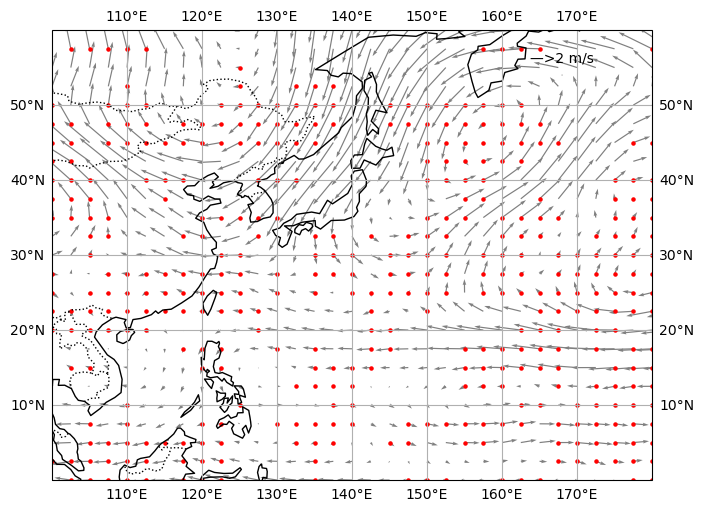

In [17]:
fig = plt.figure(figsize=(15,15))
ax6 = fig.add_axes([0.1, 0.1, 0.4, 0.3], projection=ccrs.PlateCarree(central_longitude=180))
ax6.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax6.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax6.add_feature(cfeature.COASTLINE)
ax6.add_feature(cfeature.BORDERS, linestyle=':')
# q = ax6.quiver(lonst.data, latst.data, u_diff.data, v_diff.data, color='k', scale=100000, zorder=10, width=0.005, transform=ccrs.PlateCarree())
q = ax6.quiver(lonst, latst, u_diff, v_diff, width = 0.002, scale = 200000,color='grey')
# ax6.text(0.98, 0.95, '—>2 m/s', transform=ax6.transAxes,
#         fontsize=12, verticalalignment='top', horizontalalignment='right',
#         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

ax6.quiverkey(q, X=0.85, Y=0.9, U=2, label='—>2 m/s',angle=0, labelpos='N')
ax6.scatter(lonst[significant_points_sst[1]], latst[significant_points_sst[0]], color='r', s=5, transform=ccrs.PlateCarree())

plt.show()

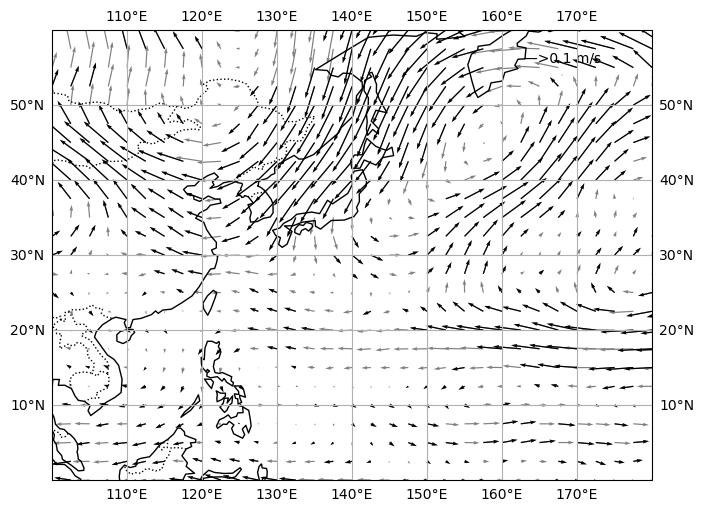

In [23]:
# Define the figure and axis
fig = plt.figure(figsize=(15, 15))
ax6 = fig.add_axes([0.1, 0.1, 0.4, 0.3], projection=ccrs.PlateCarree(central_longitude=180))
ax6.set_extent([100, 180, 0, 60], crs=ccrs.PlateCarree())
ax6.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax6.add_feature(cfeature.COASTLINE)
ax6.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the general vector field with gray arrows
q = ax6.quiver(lonst, latst, u_diff, v_diff, width=0.002, scale=200000, color='grey')

# Masked arrays for significant vectors
u_significant = np.where(significant_sst & significant_sstv, u_diff, np.nan)
v_significant = np.where(significant_sst & significant_sstv, v_diff, np.nan)

# Plot significant vectors with red arrows
q_significant = ax6.quiver(lonst, latst, u_significant, v_significant, width=0.002, scale=200000, color='k')

# Add a quiver key to indicate the scale
ax6.quiverkey(q, X=0.85, Y=0.9, U=0.1, label='—>0.1 m/s', angle=0, labelpos='N')

# Show the plot
plt.show()


In [21]:
u_flattened = u_diff.values.flatten()
v_flattened = v_diff.values.flatten()
data_dict = {
    'u_diff':u_flattened,
    'v_diff':v_flattened,
}
df = pd.DataFrame(data_dict)
output_file_path = 'string.xlsx'
df.to_excel(output_file_path, index=False)
output_file_path

'string.xlsx'

In [22]:
aaa=np.nan_to_num(u_significant)
bbb=np.nan_to_num(v_significant)

u_flattenedsig = aaa.flatten()
v_flattenedsig = bbb.flatten()
data_dict = {
    'u_diffsig':u_flattenedsig,
    'v_diffsig':v_flattenedsig,
}
df = pd.DataFrame(data_dict)
output_file_path = 'stringsig.xlsx'
df.to_excel(output_file_path, index=False)
output_file_path

'stringsig.xlsx'